# First Steps Towards Stochastic Expectation-Maximization

In this notebook, I'll describe and demonstrate an early version of *stochastic expectation maximization* (SEM), a technique that I learned about primarily from [this paper](https://proceedings.neurips.cc/paper_files/paper/2018/hash/aba22f748b1a6dff75bda4fd1ee9fe07-Abstract.html). This framework applies when the joint distribution between latent and observed variables is in an exponential family, which is indeed true in our case. 

### SEM

I implemented the calculation of the basic SEM update. This update consists in performing an EM-like parameter update using a *single* edge and modifying the current estimate accordingly. Suppose that we have a current estimate $\hat{\theta}^{(t)}$ at time $t$, and that in step $t+1$ we get an update $\theta'$. Then, the basic new estimate in the SEM framework is 

$$
\hat{\theta}^{(t+1)}  = (1-\rho^{(t)})\hat{\theta}^{(t)} + \rho^{(t)}\theta'. 
$$

We can think of $\rho^{(t)}$ as a learning rate that tunes how quickly the parameter update occurs. As in other optimization frameworks, it is possible to choose $\rho^{(t)}$ to decrease over time. In the cited paper above, the authors instead take a different approach in which they modify the update in order to make it unnecessary to tune the learning rate. 

### *What I Did*

I implemented the *simplest* version of SEM. In this version, we first sample an edge $e$. From $e$, we then compute a vector of *expected sufficient statistics* with respect to the distribution over possible edges that could have generated $e$. These expectations summarize the important features of the data. From these expectations, it is then possible to form the update $\theta'$, after which we can iterate the equation above until (hopefully) convergence. 

The approach I used involves an approximation: we approximate that the number of nodes added from the remainder of the hypergraph is Poisson with expectation $\gamma$, rather than binomial with parameter $\gamma/N$. This *should* be ok when $N$ is large. Because the algorithm doesn't seem to be working perfectly, this is one thing that we might want to take another look at later. 

### *Findings*

So far, what I've found is that *this works sometimes*. In particular, there are settings of the parameters where this algorithm performs very well, in practical time, on large hypergraphs. Here's an example of estimating the parameters on a hypergraph with 1M edges and roughly 1M nodes. 

In [1]:
%load_ext autoreload
%autoreload 2

import importlib 
m = importlib.import_module(".model", "src")
sem = importlib.import_module(".sem", "src") # my implementation of baby SEM

from matplotlib import pyplot as plt
import numpy as np

In [2]:
# generate some sample data

eta   = 0.7   # node retention in edges
beta  = 1.2   # poisson number of novel nodes
gamma = 0.8   # poisson number of nodes from graph

timesteps = int(1e6)

H = m.GrowingHypergraph()
H.add_edge((0, 1))
H.add_edge((2, 3))

for _ in range(timesteps):
    H.sample_edge(eta, gamma, beta, True)
    
print(f"This hypergraph has {len(H.edge_size_sequence())} edges and {len(H.degree_sequence())} nodes.")

This hypergraph has 1000002 edges and 1199945 nodes.


In [3]:
# initialize a model with 
# initial parameter guesses
EM = sem.SEM(H, pars = {"eta"   : 0.3, 
                        "beta"  : 0.4, 
                        "gamma" : 0.02})

In [4]:
# track the parameter estimates over time
ETA   = []
BETA  = []
GAMMA = []
steps = 5000

# main loop
for i in range(steps):

    if i % 250 == 0:
        print("--------")
        print(f"Completed step {i}")
        print(EM.pars)
        
        
    EM.SEM_step(0.002) # both the stochastic E and the M steps are in here
    ETA.append(EM.pars["eta"])
    BETA.append(EM.pars["beta"])
    GAMMA.append(EM.pars["gamma"])

--------
Completed step 0
{'eta': 0.3, 'beta': 0.4, 'gamma': 0.02}
--------
Completed step 250
{'eta': 0.4486719781967829, 'beta': 0.6856002823639428, 'gamma': 0.33459869040308066}
--------
Completed step 500
{'eta': 0.5453168010009115, 'beta': 0.8649425456074809, 'gamma': 0.5442518530562008}
--------
Completed step 750
{'eta': 0.596146767061672, 'beta': 0.9494778627424669, 'gamma': 0.6419290592081285}
--------
Completed step 1000
{'eta': 0.6366011945829393, 'beta': 1.0707808264048537, 'gamma': 0.7012733017107121}
--------
Completed step 1250
{'eta': 0.6521894954656418, 'beta': 1.1221679746264765, 'gamma': 0.7362312064540932}
--------
Completed step 1500
{'eta': 0.6738637461441896, 'beta': 1.1424192308091274, 'gamma': 0.7743599211635046}
--------
Completed step 1750
{'eta': 0.6882283167694556, 'beta': 1.1466317485975632, 'gamma': 0.7579982300192114}
--------
Completed step 2000
{'eta': 0.6868012310506364, 'beta': 1.1518083546145075, 'gamma': 0.7783903989327907}
--------
Completed step 

On a medium-powerful computer (the head node of Middlebury's compute cluster), this took about 8 minutes.  

ValueError: x and y must have same first dimension, but have shapes (5000,) and (2094,)

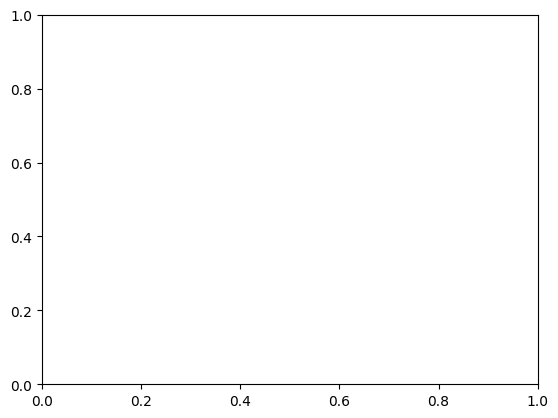

In [ ]:
# how'd we do?     
T = np.arange(steps)
plt.plot(T, ETA,   label = "eta", color = "blue")
plt.plot(T, BETA,  label = "beta", color = "black")
plt.plot(T, GAMMA, label = "gamma", color = "grey")

plt.plot(T, np.ones((steps,))*eta, color = "blue", linestyle = "dashed")
plt.plot(T, np.ones((steps,))*beta, color = "black", linestyle = "dashed")
plt.plot(T, np.ones((steps,))*gamma, color = "grey", linestyle = "dashed")

plt.gca().set(xlabel = "algorithmic timestep", ylabel = "parameter value")
plt.legend()

That looks pretty promising! 

## A Less Successful Example 

On the other hand, I have also observed cases, especially when the parameters are small, with less good performance. Here's a smaller example: 

This hypergraph has 10002 edges and 5098 nodes.
--------
Completed step 0
{'eta': 0.3013003509710652, 'beta': 0.3992, 'gamma': 0.019960027418808264}
--------
Completed step 250
{'eta': 0.4149265013481701, 'beta': 0.440147945361957, 'gamma': 0.12942368587821104}
--------
Completed step 500
{'eta': 0.49241126540113783, 'beta': 0.4520592629314658, 'gamma': 0.2187882499211593}
--------
Completed step 750
{'eta': 0.5442031430970686, 'beta': 0.4712840836455246, 'gamma': 0.26151402366255316}
--------
Completed step 1000
{'eta': 0.5742983433869904, 'beta': 0.48120292378600044, 'gamma': 0.278643022813578}
--------
Completed step 1250
{'eta': 0.6000225412648903, 'beta': 0.5018925410326667, 'gamma': 0.28355018316714414}
--------
Completed step 1500
{'eta': 0.6214093573367819, 'beta': 0.501733857178911, 'gamma': 0.26725453496000284}
--------
Completed step 1750
{'eta': 0.6114116161593314, 'beta': 0.4956550442575531, 'gamma': 0.29128895015836276}
--------
Completed step 2000
{'eta': 0.6373454225645

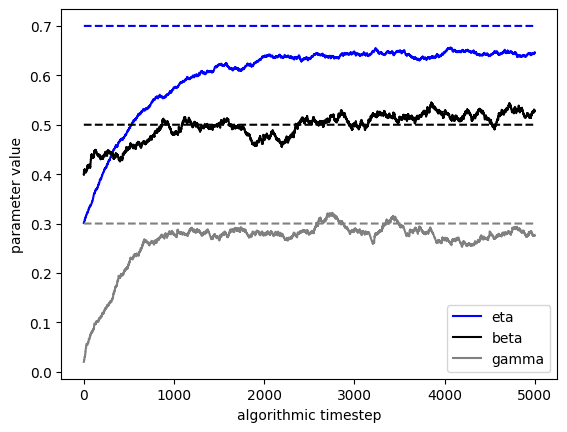

In [ ]:
# generate some sample data

eta   = 0.7   # node retention in edges
beta  = 0.5   # poisson number of novel nodes
gamma = 0.3   # poisson number of nodes from graph

timesteps = int(1e4)

H = m.GrowingHypergraph()
H.add_edge((0, 1))
H.add_edge((2, 3))

for _ in range(timesteps):
    H.sample_edge(eta, gamma, beta, True)
    
print(f"This hypergraph has {len(H.edge_size_sequence())} edges and {len(H.degree_sequence())} nodes.")

# initialize a model with 
# initial parameter guesses
EM = sem.SEM(H, pars = {"eta"   : 0.3, 
                        "beta"  : 0.4, 
                        "gamma" : 0.02})

# track the parameter estimates over time
ETA   = []
BETA  = []
GAMMA = []
steps = 5000

for i in range(steps):

    EM.SEM_step(0.002) # both the stochastic E and the M steps are in here
    if i % 250 == 0:
        print("--------")
        print(f"Completed step {i}")
        print(EM.pars)
    ETA.append(EM.pars["eta"])
    BETA.append(EM.pars["beta"])
    GAMMA.append(EM.pars["gamma"])
    
# how'd we do?     
T = np.arange(steps)
plt.plot(T, ETA,   label = "eta", color = "blue")
plt.plot(T, BETA,  label = "beta", color = "black")
plt.plot(T, GAMMA, label = "gamma", color = "grey")

plt.plot(T, np.ones((steps,))*eta, color = "blue", linestyle = "dashed")
plt.plot(T, np.ones((steps,))*beta, color = "black", linestyle = "dashed")
plt.plot(T, np.ones((steps,))*gamma, color = "grey", linestyle = "dashed")

plt.gca().set(xlabel = "algorithmic timestep", ylabel = "parameter value")
plt.legend()

The estimates for $\beta$ and $\gamma$ look ok, but the estimate for $\eta$ is noticeably lower than it should be. I'm uncertain whether this is a statistical bias in the maximum-likelihood framework, or whether there's some opportunity to actually improve the algorithm in such a way that we fix this issue. 

## What Should We Do Next?

- Implement the variance-reduced version of SEM from Chen et al. so that it's not necessary to worry about the learning rate $\rho$. I think this would involve a modified update and the calculation of an expectation over the entire data set in each epoch, which is considerably more complicated. 
- Speed optimizations!! I made no attempts to make my implementation fast at all, and so I am pretty confidence that it could be improved. Some possibilities include: 
    - Memoizing the edge neighborhood (set of overlapping edges). Currently this is queried fresh each step, but storing it as we build it up could allow for faster queries long-term. 
    - More generally, using XGI in a smarter way for faster edge-set queries? 
    - Better use of numpy and stuff? 
    - Actually, performance profiling, because right now I don't actually know exactly what the bottlenecks are in the algorithm. 
- Can we improve the performance of the algorithm for *all* parameter values? This might involve trying to change the Poisson approximation used in the code, or maybe just understanding whether there is some kind of important bias in maximum-likelihood estimation here that we need to understand better. 

